# Brain Tumor MRI Classification
### A custom CNN and VGG16 transfer-learning comparison

**Author: Abdelrahman Mohamed**  
**Task:** Binary image classification · **Input:** 128 × 128 RGB · **Framework:** TensorFlow / Keras

This project trains a custom convolutional neural network and a frozen-backbone VGG16 model to classify MRI images using the dataset's `yes` and `no` labels. It includes image exploration, augmentation, training callbacks, test evaluation, and model export.

> **Presentation update:** The original executable cell, training logs, figures, predictions, warnings, and execution metadata are preserved without rerunning the notebook.

## Contents
1. [Project overview](#project-overview)
2. [Data and preprocessing](#data-and-preprocessing)
3. [Model architectures](#model-architectures)
4. [Training configuration](#training-configuration)
5. [Run the notebook](#run-the-notebook)
6. [Implementation and saved outputs](#implementation-and-saved-outputs)
7. [Recorded results](#recorded-results)
8. [Model artifacts](#model-artifacts)
9. [Interpretation and reproducibility](#interpretation-and-reproducibility)


## Project overview
The notebook compares two approaches to the same binary classification task:

- **Custom CNN:** Learn convolutional features directly from the training images.
- **VGG16 transfer learning:** Keep the ImageNet-pretrained convolutional backbone frozen and train a classification head.

The labels represent the dataset's tumor-present (`yes`) and tumor-absent (`no`) categories. This experiment performs image classification; it does not locate a tumor, segment an image, or predict a tumor subtype.

## Data and preprocessing
The implementation downloads `brain_tumor.zip` with `gdown` using the Google Drive file ID embedded in the original code. It extracts the archive into `/content/` and expects the following directories:

| Directory | Label |
| --- | --- |
| `/content/yes` | `yes` |
| `/content/no` | `no` |

Images are resized to **128 × 128**, converted to **RGB**, and divided by **255.0**. Labels are encoded with `LabelEncoder` and converted to two-column categorical targets. Files that fail to load are silently skipped by the original loader.

| Partition | Approximate share | Method |
| --- | ---: | --- |
| Training | 70% | First stratified split |
| Validation | 15% | Half of the remaining 30% |
| Test | 15% | Other half of the remaining 30% |

Both splits use `random_state=42`. The saved CNN report contains **450 test images**, with **225 images per class**. Total successfully loaded image counts are not explicitly printed.

### Training augmentation
The training generator applies rotation up to 10°, zoom of 0.1, width and height shifts of 0.1, and horizontal flips. Validation and test arrays are evaluated without this generator. The notebook displays six example images and six augmented views of one training image.


## Model architectures

### Custom CNN

| Layer | Configuration |
| --- | --- |
| Convolution | 32 filters, 3 × 3 kernel, ReLU |
| Max pooling | 2 × 2 |
| Convolution | 64 filters, 3 × 3 kernel, ReLU |
| Max pooling | 2 × 2 |
| Flatten | Converts feature maps to a vector |
| Dense | 128 units, ReLU |
| Dropout | 0.5 |
| Output | 2 units, softmax |

The saved model summary reports **7,392,578 parameters**, all trainable.

### VGG16 transfer learning

| Component | Configuration |
| --- | --- |
| Backbone | VGG16, ImageNet weights, `include_top=False` |
| Backbone training | All backbone layers frozen |
| Pooling | Global average pooling |
| Dense head | 128 units, ReLU |
| Dropout | 0.3 |
| Output | 2 units, softmax |

Only the added classification head is trained. The notebook does not unfreeze the VGG16 backbone for fine-tuning.

## Training configuration

| Setting | Custom CNN | VGG16 |
| --- | --- | --- |
| Optimizer | Adam | Adam |
| Loss | Categorical cross-entropy | Categorical cross-entropy |
| Batch size | 32 | 32 |
| Maximum epochs | 20 | 10 |
| Validation | Separate validation arrays | Same validation arrays |

The callback list contains early stopping with patience 5 and best-weight restoration, learning-rate reduction with patience 3 and factor 0.2, and a best-model checkpoint. The same callback instances are reused for both fits.

## Run the notebook
1. Open this notebook in **Google Colab**; its shell command and `/content/` paths are written for that environment.
2. Ensure the runtime can access the configured Google Drive archive and download VGG16's ImageNet weights.
3. Run the implementation cell. It downloads and extracts the data, trains both models, evaluates them, and writes the model files.
4. Review the saved plots and metrics, then download the generated `.keras` files if you want to retain them outside the runtime.

Dependencies include TensorFlow/Keras, NumPy, Matplotlib, seaborn, Pillow, scikit-learn, and gdown. The original code installs gdown inside the cell; exact versions of the other packages are not pinned. A GPU runtime can accelerate the training workload.

## Implementation and saved outputs
The original workflow remains in one code cell so that its training logs and figures stay attached to the code that produced them. Inline step comments provide navigation through the executable workflow.


Downloading...
From (original): https://drive.google.com/uc?id=1WJ2UUdJtUfWXrvlKjgaIcd7VPY3pWpdY
From (redirected): https://drive.google.com/uc?id=1WJ2UUdJtUfWXrvlKjgaIcd7VPY3pWpdY&confirm=t&uuid=f97cd062-a553-44b3-ae2b-996fb8c84d40
To: /content/brain_tumor.zip
100%|██████████| 88.1M/88.1M [00:00<00:00, 116MB/s]


 Dataset Extracted!


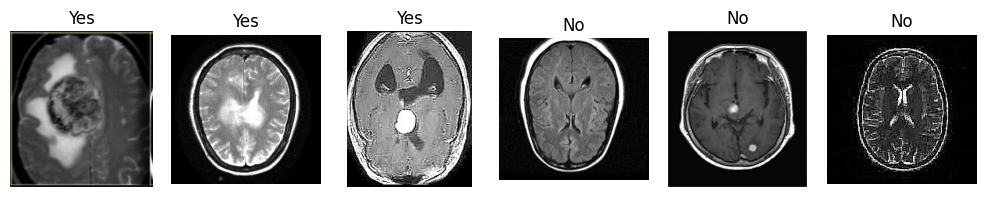

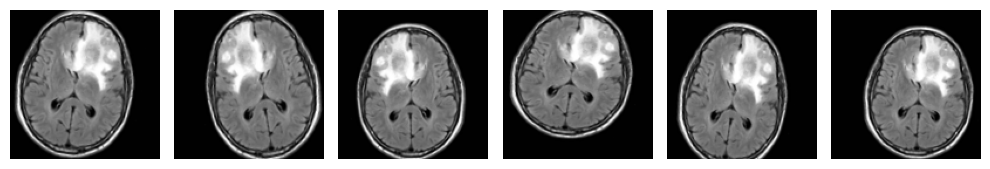

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,578 (28.20 MB)

 Trainable params: 7,392,578 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 67s 977ms/step - accuracy: 0.6363 - loss: 0.8619 - val_accuracy: 0.7556 - val_loss: 0.5231 - learning_rate: 0.0010
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.7593 - loss: 0.5223 - val_accuracy: 0.7822 - val_loss: 0.4610 - learning_rate: 0.0010
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 66s 994ms/step - accuracy: 0.7479 - loss: 0.5198 - val_accuracy: 0.7756 - val_loss: 0.5678 - learning_rate: 0.0010
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 62s 934ms/step - accuracy: 0.7798 - loss: 0.4730 - val_accuracy: 0.8044 - val_loss: 0.4157 - learning_rate: 0.0010
Epoch 5/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 63s 961ms/step - accuracy: 0.7904 - loss: 0.4555 - val_accuracy: 0.8200 - val_loss: 0.4112 - learning_rate: 0.0010
Epoch 6/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.7858 - loss: 0.4711 - val_accuracy: 0.8244 - val_loss: 0.3931 - learning_rate: 0.0010
Epoch 7/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.8061 - loss: 0.4227 - va

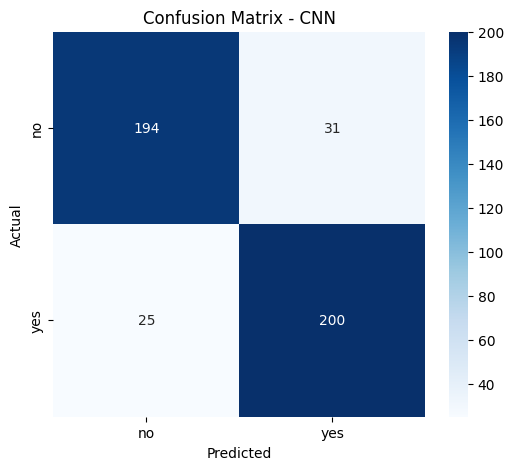

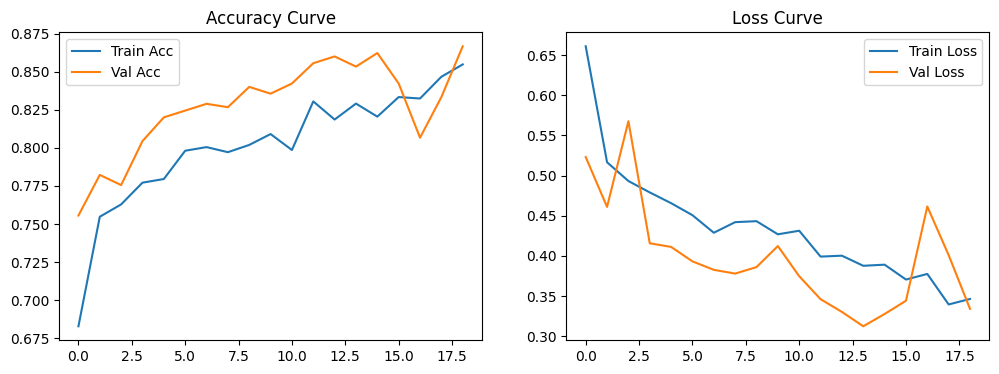

15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 172ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 516s 8s/step - accuracy: 0.6281 - loss: 0.6265 - val_accuracy: 0.8289 - val_loss: 0.4054 - learning_rate: 0.0010
Epoch 2/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 561s 9s/step - accuracy: 0.7797 - loss: 0.4680 - val_accuracy: 0.8578 - val_loss: 0.3387 - learning_rate: 0.0010
Epoch 3/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 560s 9s/step - accuracy: 0.8402 - loss: 0.3695 - val_accuracy: 0.8622 - val_loss: 0.3027 - learning_rate: 0.0010
Epoch 4/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 562s 9s/step - accuracy: 0.8618 - loss: 0.3340 - val_accuracy: 0.8689 - val_loss: 0.2886 - learning_rate: 0.0010
Epoch 5/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 506s 8s/step - accuracy: 0.8738 - loss: 0.3130 - val_accuracy: 0.8867 - val_loss: 0.2581 - learning_rate: 0.0010
Epoch 6/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 560s 8s/step - accuracy: 0.8853 - loss: 0.2951 - val_accuracy: 0.8933 - val_loss: 0.2491 - learning_rate: 0.0010
Epoch 7/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 500s 8s/step - accuracy: 0.8858 - loss: 0.2773 - val_acc

In [ ]:
# Deep learning Project – Brain Tumor MRI
# Done by: Abdelrahman Mohamed
# Step 1: Import libraries
import os, zipfile, random, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import VGG16

# Step 2: load dataset from Google Drive
!pip install -q gdown
import gdown
gdown.download(id="1WJ2UUdJtUfWXrvlKjgaIcd7VPY3pWpdY", output="brain_tumor.zip", quiet=False)

# Step 3: Extract dataset
with zipfile.ZipFile("brain_tumor.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/")
print(" Dataset Extracted!")

#Step 4:  image size and data paths
img_size = 128
yes_dir = "/content/yes"
no_dir = "/content/no"

# Step 5: Visualize
sample_yes = os.listdir(yes_dir)[:3]
sample_no = os.listdir(no_dir)[:3]
plt.figure(figsize=(10, 2))
for i, file in enumerate(sample_yes + sample_no):
    img_path = os.path.join(yes_dir if i < 3 else no_dir, file)
    img = Image.open(img_path)
    plt.subplot(1, 6, i + 1)
    plt.imshow(img)
    plt.title("Yes" if i < 3 else "No")
    plt.axis('off')
plt.tight_layout()
plt.show()

#  Step 6: Load preprocess images
X, y = [], []
def load_images(folder, label):
    for file in os.listdir(folder):
        try:
            img = Image.open(os.path.join(folder, file)).resize((img_size, img_size)).convert("RGB")
            X.append(np.array(img))
            y.append(label)
        except:
            pass
load_images(yes_dir, "yes")
load_images(no_dir, "no")
X = np.array(X) / 255.0
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_cat = to_categorical(y_encoded)

#  Step 7: Split dataset
X_train, X_temp, y_train, y_temp = train_test_split(X, y_cat, test_size=0.3, stratify=y_cat, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

# Step 8: Augmentation
datagen = ImageDataGenerator(rotation_range=10, zoom_range=0.1, width_shift_range=0.1,
                             height_shift_range=0.1, horizontal_flip=True)
datagen.fit(X_train)

#  Step 9: Visualize augmented
aug_iter = iter(datagen.flow(X_train[:1], batch_size=1))
plt.figure(figsize=(10,2))
for i in range(6):
    plt.subplot(1,6,i+1)
    plt.imshow(next(aug_iter)[0])
    plt.axis('off')
plt.tight_layout()
plt.show()

# Step 10: Build CNN
cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(img_size, img_size, 3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')
])

# Step 11: Compile CNN
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Step 12: Model Summary
cnn_model.summary()

# Step 13:  callbacks
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.2),
    ModelCheckpoint("best_cnn.keras", save_best_only=True)
]

# Step 14: Train model
history = cnn_model.fit(datagen.flow(X_train, y_train, batch_size=32),
                        validation_data=(X_val, y_val),
                        epochs=20, callbacks=callbacks)

# Step 15: Evaluate
loss, acc = cnn_model.evaluate(X_test, y_test)
print(f"CNN Accuracy: {acc*100:.2f}%")

# Step 16: Classification Report
y_pred = np.argmax(cnn_model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)
print(classification_report(y_true, y_pred, target_names=le.classes_))

# Step 17: Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix - CNN")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()

# Step 18: Plot accuracy/loss
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy Curve"); plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss Curve"); plt.legend()
plt.show()

#  Step 19: Predict
predictions = cnn_model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)

# Step 20: Optional Fine tuning if need

# Step 21: Save CNN
cnn_model.save("cnn_model_final.keras")

# Step 22: Transfer Learning VGG16
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))
for layer in base_model.layers:
    layer.trainable = False
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(2, activation='softmax')(x)
vgg_model = Model(inputs=base_model.input, outputs=output)

vgg_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
vgg_model.fit(datagen.flow(X_train, y_train, batch_size=32),
              validation_data=(X_val, y_val), epochs=10, callbacks=callbacks)
loss_vgg, acc_vgg = vgg_model.evaluate(X_test, y_test)
print(f" VGG16 Accuracy: {acc_vgg*100:.2f}%")
vgg_model.save("vgg16_model_final.keras")


## Recorded results
These values are transcribed from the existing output. No models were retrained during the Markdown update.

| Model | Printed test accuracy |
| --- | ---: |
| Custom CNN | 87.56% |
| VGG16 with frozen backbone | 91.56% |

VGG16's printed accuracy is **4.00 percentage points higher** on this test split. This single-run comparison does not establish statistical significance or generalization to other datasets.

### Custom CNN classification report

| Class | Precision | Recall | F1-score | Support |
| --- | ---: | ---: | ---: | ---: |
| `no` | 0.89 | 0.86 | 0.87 | 225 |
| `yes` | 0.87 | 0.89 | 0.88 | 225 |
| Macro average | 0.88 | 0.88 | 0.88 | 450 |
| Weighted average | 0.88 | 0.88 | 0.88 | 450 |

The class metrics are rounded as printed. The original notebook also includes the CNN confusion matrix and training/validation accuracy and loss curves. A separate VGG16 classification report and confusion matrix are not generated.

## Model artifacts

| Generated file | Purpose |
| --- | --- |
| `best_cnn.keras` | Checkpoint path reused by the callback list during both model fits |
| `cnn_model_final.keras` | Custom CNN saved after evaluation |
| `vgg16_model_final.keras` | VGG16-based model saved after evaluation |

Because the checkpoint callback is reused, `best_cnn.keras` can be overwritten during VGG16 training; its name alone does not establish that it still contains the CNN. The two final model filenames are distinct. The model files are generated at runtime and are not embedded in this notebook.

## Interpretation and reproducibility

- **Split scope:** The code splits images, not patient identifiers. Patient-level separation, duplicate-image checks, and external validation are not shown.
- **Data provenance:** The notebook specifies a download location but does not document dataset authorship, patient counts, acquisition details, or licensing.
- **VGG16 input handling:** Both models receive RGB arrays scaled to `[0, 1]`. The code does not call VGG16's `preprocess_input`; the documented results reflect the implemented preprocessing.
- **Randomness:** The data split has a fixed seed, but model initialization and augmentation are not fully seeded. File iteration order is not explicitly sorted, so reruns need not reproduce the same results.
- **Saved inference context:** The `.keras` models do not bundle the PIL image-loading steps or separately serialize the label encoder. Reuse requires matching the input resizing, RGB conversion, normalization, and label mapping.
- **Scope of use:** This is an educational image-classification experiment. The notebook does not establish clinical diagnostic performance.

---
*Only Markdown presentation and explanatory text were updated. Executable content and saved outputs remain unchanged.*
